# About Dataset

## Context

* "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

## Content

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

* **Customers who left within the last month** – the column is called `Churn`
* **Services that each customer has signed up for** – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* **Customer account information** – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
* **Demographic info about customers** – gender, age range, and if they have partners and dependents


## Exploration and Data loading

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv(r'C:\Users\thisu\Desktop\practicing for intern\AI PROJ1(churn)\PROJ\data\raw\raw.csv')
df.shape

(7043, 21)

In [15]:
df1 = pd.read_csv(r'C:\Users\thisu\Desktop\practicing for intern\AI PROJ1(churn)\PROJ\data\raw\raw.csv')
df1.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [16]:
df1.head(1).T

,0
customerID,7590-VHVEG
gender,Female
SeniorCitizen,0
Partner,Yes
Dependents,No
tenure,1
PhoneService,No
MultipleLines,No phone service
InternetService,DSL
OnlineSecurity,No


In [17]:
pd.set_option('display.max_columns', None) #to display all columns in dataframe
pd.set_option('display.max_rows', None) #to display all rows in dataframe

In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


* Based on the `.describe()` (and exploration) we can see that most categorical variables have between 2, 3, or 4 categories
                "# Collapse redundant dummy columns before running VIF",
                "internet_no_service_cols = [",
                "    col for col in df.columns",
                "    if col.endswith('No internet service')",
                "]",
                "",
                "if internet_no_service_cols:",
                "    df['No_Internet_service'] = df[internet_no_service_cols].any(axis=1).astype(int)",
                "    df = df.drop(columns=internet_no_service_cols)",
                "",
                "phone_no_service_cols = [col for col in df.columns if col.endswith('No phone service')]",
                "if phone_no_service_cols:",
                "    df['No_phone_service'] = df[phone_no_service_cols[0]].astype(int)",
                "    df = df.drop(columns=phone_no_service_cols)"
<VSCode.Cell id="#VSC-8c59a13d" language="python">
df.head()

# One-hot-Encoding

In [20]:
# Categorical columns with more than 2 unique values

multi_cat_cols = [
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaymentMethod'
]

# One-hot encoding
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,0,Yes,No,1,No,Yes,29.85,29.85,No,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,56.95,1889.5,No,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,Male,0,No,No,2,Yes,Yes,53.85,108.15,Yes,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,Male,0,No,No,45,No,No,42.30,1840.75,No,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,Female,0,No,No,2,Yes,Yes,70.70,151.65,Yes,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


# Cleaning

In [22]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [23]:
df = df.drop('customerID', axis=1)

In [24]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)  # converts True/False to 1/0 for all boolean columns

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   object 
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   object 
 3   Dependents                             7043 non-null   object 
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   object 
 6   PaperlessBilling                       7043 non-null   object 
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   object 
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

C:\Users\thisu\AppData\Local\Temp\ipykernel_28076\2329088022.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


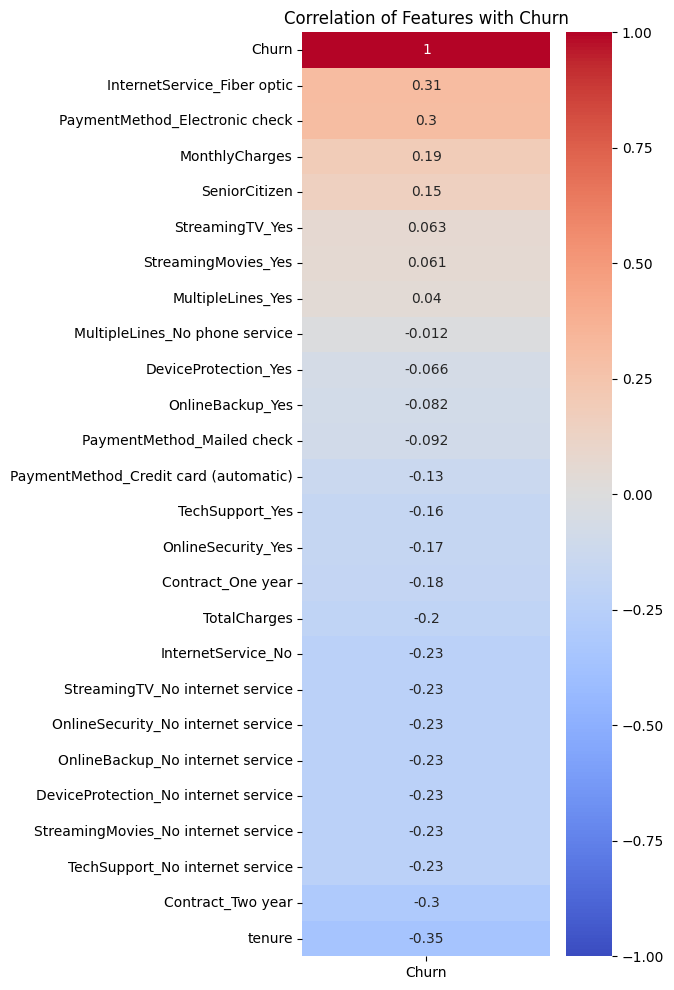

In [29]:
# Convert target to numeric so it is included in the correlation matrix
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with 'Churn'
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

#plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

In [28]:
df['Churn'].dtype
df['Churn'].head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

Negative (lower valure - less likely to churn):
* tenure(-0.35) - Customers who stays longer are less likely to churn
* Contact_Two year (-0.30) - Customers on long-term contracts churn much less
* Contract_One year (-0.18) - Same trend but weaker than 2 year contracts

Positive (higher value - more likely to churn)
* InternetService_Fiber optic (+0.31) - Fiber optic users churn more in this dataset
* PaymentMethod_Electronic check (+0.30) - Customers paying electronically via check churn more

# Look for multicolinearity(VIF-Variance Inflation Factor)

In [38]:
# Collapse redundant dummy columns before running VIF in a rerunnable way
internet_no_service_source_cols = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
]

internet_no_service_cols = [col for col in internet_no_service_source_cols if col in df.columns]
if internet_no_service_cols:
    df['No_Internet_service'] = df[internet_no_service_cols].any(axis=1).astype(int)
    df = df.drop(columns=internet_no_service_cols)

# Drop the duplicate indicator that matches No_Internet_service exactly
if 'InternetService_No' in df.columns:
    df = df.drop(columns=['InternetService_No'])

phone_no_service_cols = [col for col in ['MultipleLines_No phone service'] if col in df.columns]
if phone_no_service_cols:
    df['No_phone_service'] = df[phone_no_service_cols[0]].astype(int)
    df = df.drop(columns=phone_no_service_cols)

In [35]:
# Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)  # Ensure all boolean columns are integers

In [39]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Keep only numeric predictors for VIF
X = df.drop(columns=['Churn']).select_dtypes(include=['number', 'bool']).copy()

# Convert boolean columns to integers
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                                  feature        VIF
2                          MonthlyCharges  37.514368
3                            TotalCharges  21.624779
1                                  tenure  20.397818
5             InternetService_Fiber optic   9.007933
13                      Contract_Two year   3.442089
11                    StreamingMovies_Yes   3.349406
10                        StreamingTV_Yes   3.288736
15         PaymentMethod_Electronic check   2.966083
17                    No_Internet_service   2.862650
4                       MultipleLines_Yes   2.733251
8                    DeviceProtection_Yes   2.525965
7                        OnlineBackup_Yes   2.454889
16             PaymentMethod_Mailed check   2.392417
9                         TechSupport_Yes   2.385196
6                      OnlineSecurity_Yes   2.287276
12                      Contract_One year   2.040480
14  PaymentMethod_Credit card (automatic)   1.987966
18                       No_phone_service   1.